In [1]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# Load dataset
df = pd.read_csv('basket_analysis.csv')
df.head()


,Unnamed: 0,Apple,Bread,Butter,Cheese,Corn,Dill,Eggs,Ice cream,Kidney Beans,Milk,Nutmeg,Onion,Sugar,Unicorn,Yogurt,chocolate
0,0,False,True,False,False,True,True,False,True,False,False,False,False,True,False,True,True
1,1,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
2,2,True,False,True,False,False,True,False,True,False,True,False,False,False,False,True,True
3,3,False,False,True,True,False,True,False,False,False,True,True,True,False,False,False,False
4,4,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
print(df.columns)


Index(['Unnamed: 0', 'Apple', 'Bread', 'Butter', 'Cheese', 'Corn', 'Dill',
       'Eggs', 'Ice cream', 'Kidney Beans', 'Milk', 'Nutmeg', 'Onion', 'Sugar',
       'Unicorn', 'Yogurt', 'chocolate'],
      dtype='object')


In [7]:
# Drop index column if it's not useful
df = df.drop(columns='Unnamed: 0')

# Ensure all values are 1/0 for market basket
basket = df.applymap(lambda x: 1 if x > 0 else 0)

basket.head()


C:\Users\vilas\AppData\Local\Temp\ipykernel_4380\2184723219.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = df.applymap(lambda x: 1 if x > 0 else 0)


,Apple,Bread,Butter,Cheese,Corn,Dill,Eggs,Ice cream,Kidney Beans,Milk,Nutmeg,Onion,Sugar,Unicorn,Yogurt,chocolate
0,0,1,0,0,1,1,0,1,0,0,0,0,1,0,1,1
1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,1,0,1,0,0,1,0,1,0,1,0,0,0,0,1,1
3,0,0,1,1,0,1,0,0,0,1,1,1,0,0,0,0
4,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [8]:
from mlxtend.frequent_patterns import apriori, association_rules

# Generate frequent itemsets
frequent_itemsets = apriori(basket, min_support=0.1, use_colnames=True)

# Generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

rules.head()


C:\Users\vilas\AppData\Roaming\Python\Python312\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Bread),(Apple),0.384384,0.383383,0.154154,0.401042,1.046059,1.0,0.006788,1.029482,0.071524,0.251223,0.028637,0.401565
1,(Apple),(Bread),0.383383,0.384384,0.154154,0.402089,1.046059,1.0,0.006788,1.029610,0.071407,0.251223,0.028759,0.401565
2,(Butter),(Apple),0.420420,0.383383,0.188188,0.447619,1.167549,1.0,0.027006,1.116289,0.247602,0.305691,0.104174,0.469240
3,(Apple),(Butter),0.383383,0.420420,0.188188,0.490862,1.167549,1.0,0.027006,1.138354,0.232730,0.305691,0.121538,0.469240
4,(Cheese),(Apple),0.404404,0.383383,0.162162,0.400990,1.045925,1.0,0.007120,1.029393,0.073721,0.259200,0.028554,0.411983


In [9]:
#Apply Apriori Algorithm
frequent_items = apriori(basket, min_support=0.02, use_colnames=True)
frequent_items.sort_values('support', ascending=False).head()


C:\Users\vilas\AppData\Roaming\Python\Python312\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
15,0.421421,(chocolate)
14,0.420420,(Yogurt)
2,0.420420,(Butter)
7,0.410410,(Ice cream)
12,0.409409,(Sugar)


In [10]:
#Generate Association Rules
rules = association_rules(frequent_items, metric='lift', min_threshold=1.2)
rules = rules.sort_values('confidence', ascending=False)
rules.head()


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
95784,"(Nutmeg, Milk, Corn, Butter, Bread)",(Kidney Beans),0.024024,0.408408,0.021021,0.875000,2.142463,1.0,0.011209,4.732733,0.546374,0.051095,0.788706,0.463235
95973,"(Unicorn, Sugar, Bread, chocolate, Kidney Beans)",(Yogurt),0.024024,0.420420,0.020020,0.833333,1.982143,1.0,0.009920,3.477477,0.507692,0.047170,0.712435,0.440476
35109,"(Nutmeg, Unicorn, Sugar, Apple)",(Corn),0.039039,0.407407,0.031031,0.794872,1.951049,1.0,0.015126,2.888889,0.507258,0.074699,0.653846,0.435519
95664,"(Corn, Sugar, Apple, Cheese, Kidney Beans)",(Unicorn),0.028028,0.389389,0.022022,0.785714,2.017811,1.0,0.011108,2.849516,0.518959,0.055696,0.649063,0.421135
51148,"(Nutmeg, Bread, Milk, Corn)",(Kidney Beans),0.042042,0.408408,0.033033,0.785714,1.923845,1.0,0.015863,2.760761,0.501282,0.079137,0.637781,0.433298


In [11]:
#Filter for High-Value Rules
strong_rules = rules[(rules['confidence'] >= 0.3) & (rules['lift'] >= 1.2)]
strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]


,antecedents,consequents,support,confidence,lift
95784,"(Nutmeg, Milk, Corn, Butter, Bread)",(Kidney Beans),0.021021,0.875000,2.142463
95973,"(Unicorn, Sugar, Bread, chocolate, Kidney Beans)",(Yogurt),0.020020,0.833333,1.982143
35109,"(Nutmeg, Unicorn, Sugar, Apple)",(Corn),0.031031,0.794872,1.951049
95664,"(Corn, Sugar, Apple, Cheese, Kidney Beans)",(Unicorn),0.022022,0.785714,2.017811
51148,"(Nutmeg, Bread, Milk, Corn)",(Kidney Beans),0.033033,0.785714,1.923845
...,...,...,...,...,...
18509,"(Bread, Butter, Apple)","(Ice cream, Corn)",0.024024,0.300000,1.560937
11789,"(Onion, Kidney Beans)","(Cheese, Corn)",0.051051,0.300000,1.646703
35609,"(Dill, Sugar, Eggs)","(Apple, Ice cream)",0.024024,0.300000,1.742442
88005,"(Nutmeg, Unicorn, Dill)","(Kidney Beans, Ice cream)",0.021021,0.300000,1.529082


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, '(chocolate)'),
  Text(1, 0, '(Yogurt)'),
  Text(2, 0, '(Butter)'),
  Text(3, 0, '(Ice cream)'),
  Text(4, 0, '(Sugar)'),
  Text(5, 0, '(Kidney Beans)'),
  Text(6, 0, '(Corn)'),
  Text(7, 0, '(Milk)'),
  Text(8, 0, '(Cheese)'),
  Text(9, 0, '(Onion)')])

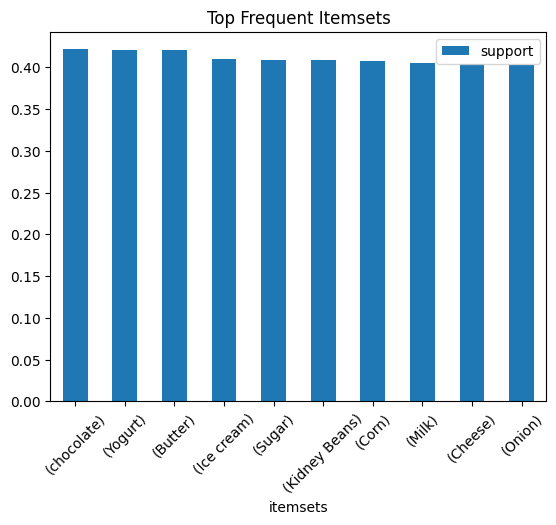

In [12]:
#Visualize Insights
frequent_items.sort_values('support', ascending=False).head(10).plot.bar(x='itemsets', y='support')
plt.title('Top Frequent Itemsets')
plt.xticks(rotation=45)


In [ ]:
#Network Graph of Rules
import networkx as nx

G = nx.from_pandas_edgelist(strong_rules, source='antecedents', target='consequents')
plt.figure(figsize=(10, 8))
nx.draw(G, with_labels=True, node_color='skyblue', node_size=3000, font_size=10)
